# Assignment 2: Kaggle Competition Boy or Girl

## 任務說明
- **目標**：根據個人資訊（身高、體重、社群數據、自我介紹等）預測性別（gender=1 或 2）
- **最佳成績**：accuracy = **0.8638**
- **方法**：LightGBM + 衍生特徵（BMI, 體型比例, log_fb_friends）+ self_intro Sentence Embedding（BAAI/bge-large-en-v1.5）+ PCA + Permutation Importance 特徵篩選

## 方法演進摘要

| 順序 | 版本 | 方法 | Kaggle 分數 | 改善 |
|---|---|---|---|---|
| 1 | SI_bge | LightGBM + bge embedding + PCA + Split Importance，無衍生特徵 | 0.8497 | 基準線 |
| 2 | **PI_bge** | LightGBM + bge embedding + PCA + **Permutation Importance** + **衍生特徵** | **0.8638** | **+0.0141** |

### 相較於前一版（SI_bge, acc=0.8497）的兩個關鍵改進：

1. **加入衍生特徵**（BMI、身高體重比、log_fb_friends）
   - BMI 和身高體重比提供了體型的交互資訊，比單獨的 height/weight 更具區分力
   - fb_friends 呈右偏分布，取 log 後分布更對稱，有助於模型學習
2. **Split Importance → Permutation Importance**
   - Split Importance 只計算特徵被樹分裂使用的次數，高基數特徵容易被高估
   - Permutation Importance 透過隨機打亂特徵值、觀察準確率下降幅度來評估真正的預測貢獻
   - 以此篩除 importance ≤ 0 的噪聲特徵，減少過擬合

## Step 1: 載入套件與資料

In [1]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

train = pd.read_csv('../data/boy_or_girl_2025_train_missingValue.csv')
test  = pd.read_csv('../data/boy_or_girl_2025_test_no_ans_missingValue.csv')

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"\nGender 分布：")
print(train['gender'].value_counts())
train.head()

Train: (423, 11), Test: (426, 11)

Gender 分布：
gender
1    316
2    107
Name: count, dtype: int64


,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro
0,1,2,處女座,Apple,154.0,43.0,NaN,NaN,583.0,0,Beautiful
1,2,2,處女座,Apple,156.0,47.0,NaN,130.0,NaN,3.5,Enjoying being who I'm notsss
2,3,1,射手座,NaN,170.0,61.0,NaN,90.0,540.0,NaN,Practice Makes perfect
3,4,1,射手座,Apple,170.0,62.0,4.0,100.0,NaN,5,Straightforward
4,5,2,射手座,Android,158.0,67.0,NaN,128.0,320.0,1.2,Humorous


## Step 2: EDA — 缺失率總覽

In [2]:
def missing_summary(df, name):
    miss = df.isnull().sum()
    pct  = miss / len(df) * 100
    return pd.DataFrame({'欄位': miss.index, '缺失數': miss.values,
                         f'{name}缺失率%': pct.values.round(1)})

print("=== Train 缺失率 ===")
display(missing_summary(train, 'train'))
print("\n=== Test 缺失率 ===")
display(missing_summary(test, 'test'))

=== Train 缺失率 ===


,欄位,缺失數,train缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,86,20.3
3,phone_os,78,18.4
4,height,74,17.5
5,weight,85,20.1
6,sleepiness,91,21.5
7,iq,79,18.7
8,fb_friends,77,18.2
9,yt,90,21.3



=== Test 缺失率 ===


,欄位,缺失數,test缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,81,19.0
3,phone_os,96,22.5
4,height,68,16.0
5,weight,96,22.5
6,sleepiness,72,16.9
7,iq,92,21.6
8,fb_friends,88,20.7
9,yt,78,18.3


## Step 3: 資料清洗

發現的髒值問題：
- `yt` 欄位含有 `#NUM!`（Excel 錯誤值），型別為 str
- `height` 範圍 -187 ~ 1e+111（離譜異常值）
- `weight` 範圍 -1000 ~ 1e+111
- `fb_friends` 範圍 -1000 ~ 3,000,000,000

處理方式：將超出合理範圍的值設為 NaN。

In [3]:
# yt 含有 '#NUM!' 等非數值，強制轉為 numeric
for df in [train, test]:
    df['yt'] = pd.to_numeric(df['yt'], errors='coerce')

# 設定合理範圍，超出範圍視為缺失
bounds = {
    'height':     (100, 250),
    'weight':     (20, 200),
    'fb_friends': (0, 10000),
    'yt':         (0, 100),
}
for df in [train, test]:
    for col, (lo, hi) in bounds.items():
        df.loc[~df[col].between(lo, hi), col] = np.nan

print("=== 清洗後缺失率 ===")
display(missing_summary(train, 'train'))

=== 清洗後缺失率 ===


,欄位,缺失數,train缺失率%
0,id,0,0.0
1,gender,0,0.0
2,star_sign,86,20.3
3,phone_os,78,18.4
4,height,81,19.1
5,weight,92,21.7
6,sleepiness,91,21.5
7,iq,79,18.7
8,fb_friends,85,20.1
9,yt,119,28.1


## Step 4: EDA — 關鍵特徵分析

### 4a. Height / Weight 的性別分布（最強特徵）

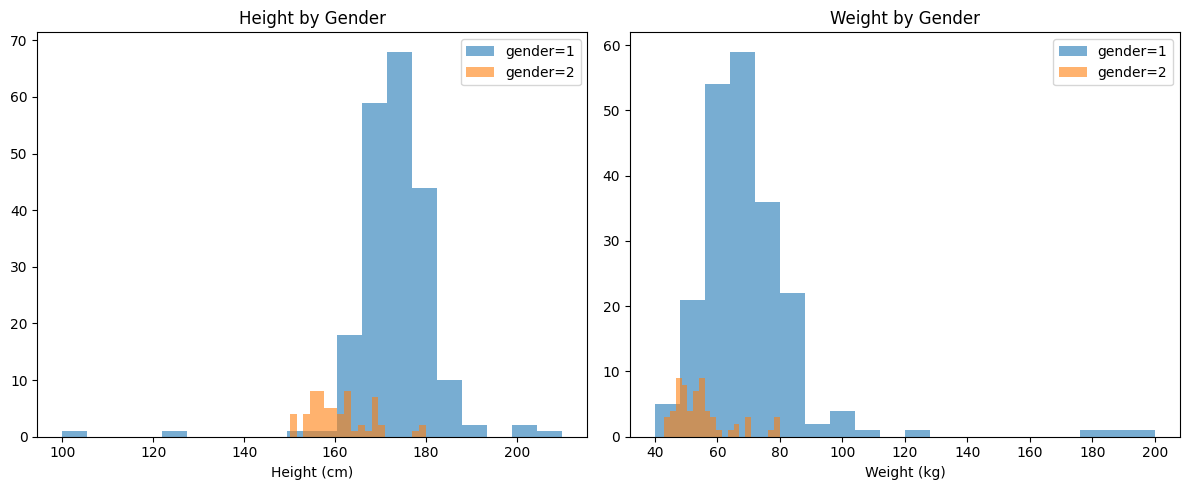

Height / Weight 的性別均值差異：


height      weight      
         mean  std   mean   std
gender                         
1       173.1  9.2   69.4  18.6
2       160.6  6.7   54.8   9.1

In [4]:
df_clean = train.dropna(subset=['height', 'weight'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for gender, grp in df_clean.groupby('gender'):
    axes[0].hist(grp['height'], bins=20, alpha=0.6, label=f'gender={gender}')
axes[0].set_title('Height by Gender')
axes[0].set_xlabel('Height (cm)')
axes[0].legend()

for gender, grp in df_clean.groupby('gender'):
    axes[1].hist(grp['weight'], bins=20, alpha=0.6, label=f'gender={gender}')
axes[1].set_title('Weight by Gender')
axes[1].set_xlabel('Weight (kg)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Height / Weight 的性別均值差異：")
display(df_clean.groupby('gender')[['height','weight']].agg(['mean','std']).round(1))

### 4b. 數值特徵相關矩陣

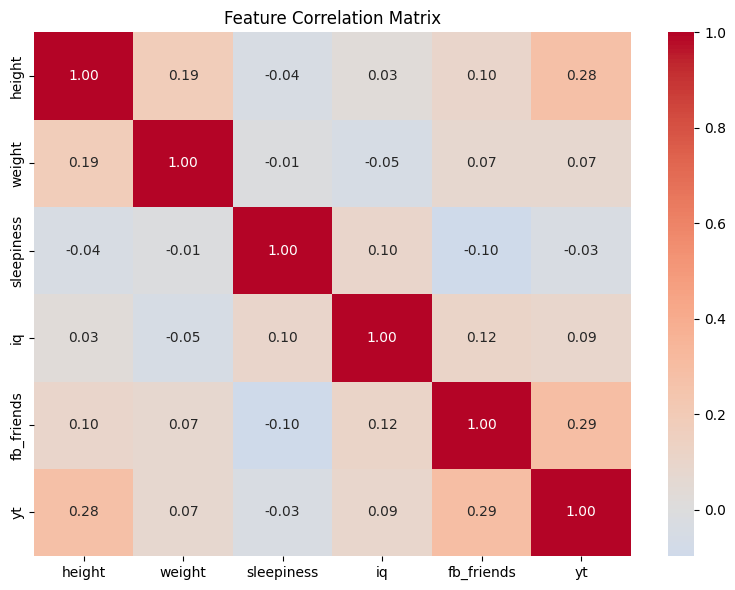

各數值欄位的 gender 分組中位數：


,height,weight,sleepiness,iq,fb_friends,yt
gender,,,,,,
1,173.0,67.0,4.0,120.0,373.0,2.0
2,160.5,53.0,3.0,128.0,491.5,2.0


In [5]:
numeric_cols = ['height', 'weight', 'sleepiness', 'iq', 'fb_friends', 'yt']

plt.figure(figsize=(8, 6))
corr = train[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print("各數值欄位的 gender 分組中位數：")
display(train.groupby('gender')[numeric_cols].median())

### 4c. self_intro 文字分析

直接觀察 gender=1 和 gender=2 的高頻詞，確認文字內容是否有性別區分度。

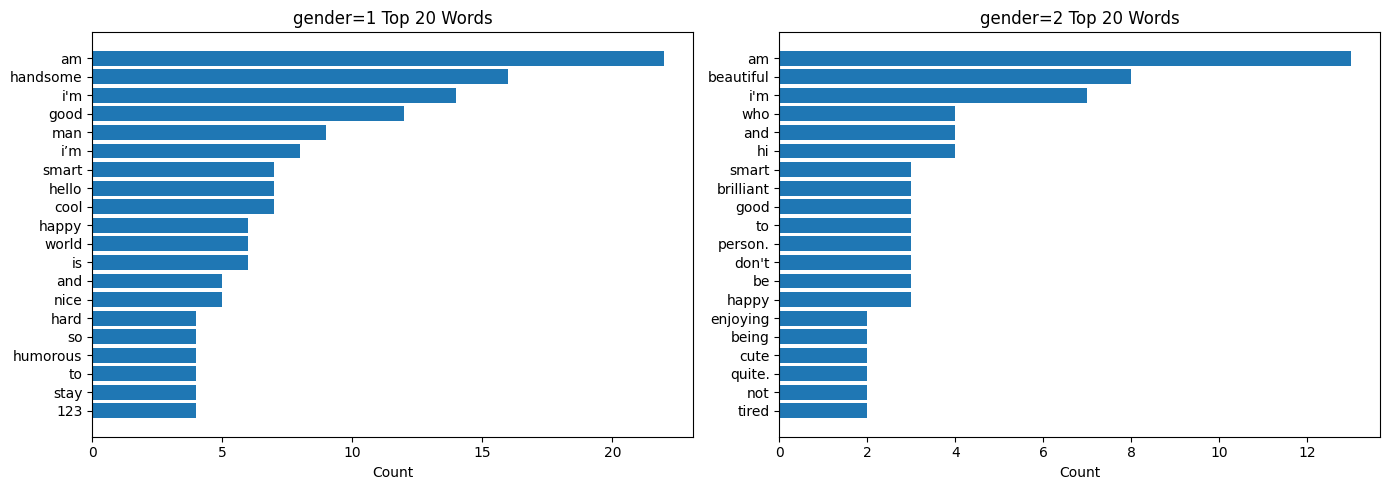

觀察：gender=1 常出現 'hard', 'work', 'handsome'；gender=2 常出現 'beautiful', 'cute', 'smart'
→ 文字用詞有明顯性別差異，適合用 Sentence Embedding 捕捉語意特徵


In [6]:
from collections import Counter

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, gender in enumerate([1, 2]):
    texts = train[train['gender']==gender]['self_intro'].dropna()
    words = ' '.join(texts).lower().split()
    words = [w for w in words if len(w) > 1]
    top20 = Counter(words).most_common(20)
    
    labels, counts = zip(*top20)
    axes[idx].barh(range(len(labels)), counts)
    axes[idx].set_yticks(range(len(labels)))
    axes[idx].set_yticklabels(labels)
    axes[idx].invert_yaxis()
    axes[idx].set_title(f'gender={gender} Top 20 Words')
    axes[idx].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("觀察：gender=1 常出現 'hard', 'work', 'handsome'；gender=2 常出現 'beautiful', 'cute', 'smart'")
print("→ 文字用詞有明顯性別差異，適合用 Sentence Embedding 捕捉語意特徵")

## Step 5: 衍生特徵工程（本版新增）

這是相較於前一版（SI_bge）的第一個改進。從現有的 height、weight、fb_friends 衍生出三個新特徵：

| 衍生特徵 | 公式 | 用途 |
|---|---|---|
| **BMI** | weight / (height/100)² | 體型指標，男女有明顯差異（男性平均 BMI 較高） |
| **height_weight_ratio** | height / weight | 體型比例，捕捉「高瘦」vs「矮胖」的差異 |
| **log_fb_friends** | log(1 + fb_friends) | fb_friends 呈右偏分布，取 log 後更對稱，減少極端值影響 |

這些衍生特徵讓模型能直接利用特徵間的交互關係，而不需要自己從原始特徵中學習這些組合。

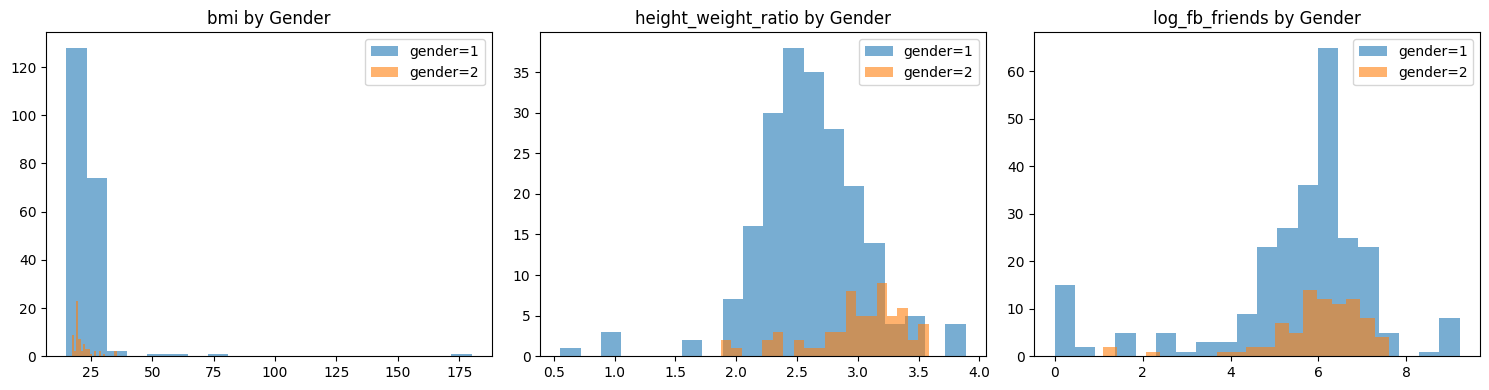

衍生特徵的性別分組統計：


bmi        height_weight_ratio       log_fb_friends      
         mean    std                mean   std           mean   std
gender                                                             
1       23.69  12.46                2.60  0.46           5.47  1.92
2       21.33   3.88                2.99  0.41           5.95  1.17

In [7]:
for df in [train, test]:
    # BMI = weight / (height_m)^2
    height_m = df['height'] / 100
    df['bmi'] = df['weight'] / (height_m ** 2)
    # 體型比例
    df['height_weight_ratio'] = df['height'] / df['weight']
    # fb_friends 右偏 → log 轉換
    df['log_fb_friends'] = np.log1p(df['fb_friends'])

# 視覺化衍生特徵的性別差異
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['bmi', 'height_weight_ratio', 'log_fb_friends']):
    for gender, grp in train.dropna(subset=[col]).groupby('gender'):
        ax.hist(grp[col], bins=20, alpha=0.6, label=f'gender={gender}')
    ax.set_title(f'{col} by Gender')
    ax.legend()
plt.tight_layout()
plt.show()

print("衍生特徵的性別分組統計：")
display(train.groupby('gender')[['bmi', 'height_weight_ratio', 'log_fb_friends']].agg(['mean', 'std']).round(2))

## Step 6: 特徵工程 — self_intro Sentence Embedding

從 4c 的詞頻分析可以看到，self_intro 的用詞存在性別差異。但單純統計詞頻（如 Bag-of-Words）有兩個問題：
1. **語意丟失**：無法區分 "I am strong" 和 "strong wind" 的差異
2. **高維稀疏**：每個詞都是一個特徵，在僅 ~400 筆資料下容易過擬合

**Sentence Transformer**（`BAAI/bge-large-en-v1.5`）能將整句話壓縮為一個 **1024 維的稠密向量**，保留語意資訊。

### 缺失值處理
- self_intro 缺失的樣本（~24%）以空字串替代，模型會輸出一個「中性向量」
- 這個中性向量不帶有性別傾向，不會引入偏差

In [8]:
from sentence_transformers import SentenceTransformer

EMBEDDING_MODEL = 'BAAI/bge-large-en-v1.5'
TRAIN_EMB_PATH  = 'train_intro_emb.npy'
TEST_EMB_PATH   = 'test_intro_emb.npy'

def get_embeddings(model, texts, fill_missing=''):
    """缺失值用空字串替代，讓模型輸出一個中性向量"""
    filled = [str(t) if pd.notna(t) and str(t).strip() != ''
              else fill_missing for t in texts]
    return model.encode(filled, show_progress_bar=True)

if os.path.exists(TRAIN_EMB_PATH) and os.path.exists(TEST_EMB_PATH):
    print("載入已存在的 embedding 快取...")
    train_emb = np.load(TRAIN_EMB_PATH)
    test_emb  = np.load(TEST_EMB_PATH)
else:
    print(f"使用 {EMBEDDING_MODEL} 生成 embedding...")
    model_st = SentenceTransformer(EMBEDDING_MODEL)
    train_emb = get_embeddings(model_st, train['self_intro'])
    test_emb  = get_embeddings(model_st, test['self_intro'])
    np.save(TRAIN_EMB_PATH, train_emb)
    np.save(TEST_EMB_PATH, test_emb)
    print("已儲存快取檔案")

print(f"Embedding shape: train={train_emb.shape}, test={test_emb.shape}")

/home/user/miniconda3/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


使用 BAAI/bge-large-en-v1.5 生成 embedding...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 1730.57it/s]
BertModel LOAD REPORT from: BAAI/bge-large-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 14/14 [00:00<00:00, 28.90it/s]

已儲存快取檔案
Embedding shape: train=(423, 1024), test=(426, 1024)


## Step 7: PCA 降維 + 特徵合併

### 為什麼需要 PCA？

Embedding 輸出是 1024 維向量，但訓練資料只有 ~400 筆。直接使用 1024 維特徵會導致：
- **維度災難**：特徵數（1024）遠大於樣本數（423），模型容易過擬合
- **雜訊放大**：高維空間中很多維度只是噪音，不包含性別資訊

PCA 將 1024 維壓縮至 10 維，只保留變異量最大的方向。

### 特徵合併
本版的特徵組成：base(3) + 衍生(3) + PCA(10) + intro_missing(1) = **17 維**

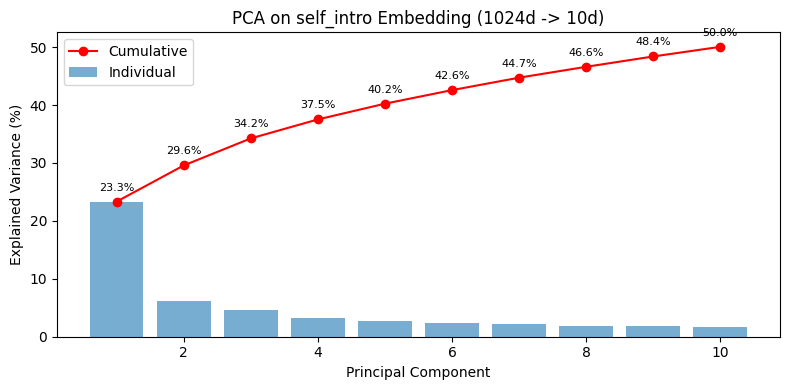

PCA 總解釋變異量：50.0%


In [9]:
from sklearn.decomposition import PCA

N_COMPONENTS = 10
pca = PCA(n_components=N_COMPONENTS, random_state=42)
train_emb_pca = pca.fit_transform(train_emb)
test_emb_pca  = pca.transform(test_emb)

# PCA 解釋變異量視覺化
fig, ax = plt.subplots(figsize=(8, 4))
cumsum = np.cumsum(pca.explained_variance_ratio_) * 100
ax.bar(range(1, N_COMPONENTS+1), pca.explained_variance_ratio_ * 100, alpha=0.6, label='Individual')
ax.plot(range(1, N_COMPONENTS+1), cumsum, 'ro-', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title(f'PCA on self_intro Embedding ({train_emb.shape[1]}d -> {N_COMPONENTS}d)')
ax.legend()
for i, v in enumerate(cumsum):
    ax.annotate(f'{v:.1f}%', (i+1, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"PCA 總解釋變異量：{pca.explained_variance_ratio_.sum():.1%}")

In [10]:
# is_missing indicator
train_intro_missing = train['self_intro'].isnull().astype(int).values.reshape(-1, 1)
test_intro_missing  = test['self_intro'].isnull().astype(int).values.reshape(-1, 1)

# 合併：base(3) + 衍生(3) + PCA(10) + intro_missing(1) = 17 維
base_features = ['height', 'weight', 'fb_friends', 'bmi', 'height_weight_ratio', 'log_fb_friends']
feature_names = base_features + [f'pca_{i}' for i in range(N_COMPONENTS)] + ['intro_missing']

X_train_full = np.hstack([train[base_features].values, train_emb_pca, train_intro_missing])
X_test_full  = np.hstack([test[base_features].values,  test_emb_pca,  test_intro_missing])

y_train = train['gender'].values

print(f"最終特徵（{len(feature_names)} 維）：{feature_names}")
print(f"X_train: {X_train_full.shape}, X_test: {X_test_full.shape}")

最終特徵（17 維）：['height', 'weight', 'fb_friends', 'bmi', 'height_weight_ratio', 'log_fb_friends', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'intro_missing']
X_train: (423, 17), X_test: (426, 17)


## Step 8: 模型設定 — LightGBM + class_weight

### class_weight 原理
資料中 gender=1 有 316 筆（75%），gender=2 只有 107 筆（25%）。如果不做處理，模型會傾向「全部猜 gender=1」就能拿到 75% 準確率，但完全無法辨識少數類。

**class_weight** 對少數類的錯誤施加更高的懲罰：
- gender=1 的 weight ≈ 0.67（降低影響力）
- gender=2 的 weight ≈ 1.98（錯分代價加倍）

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import lightgbm as lgb

# Label encoding
label_map = {v: i for i, v in enumerate(sorted(np.unique(y_train)))}
y_encoded = np.array([label_map[v] for v in y_train])
inv_label_map = {v: k for k, v in label_map.items()}

# Class weight
n_total = len(y_encoded)
class_weight_dict = {
    label_map[cls]: n_total / (len(label_map) * count)
    for cls, count in zip(*np.unique(y_train, return_counts=True))
}
print(f"Label mapping：{label_map}")
print(f"Class weights：{class_weight_dict}")

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_samples=10,
    class_weight=class_weight_dict,
    random_state=42,
    verbose=-1
)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', model)
])

Label mapping：{np.int64(1): 0, np.int64(2): 1}
Class weights：{0: np.float64(0.6693037974683544), 1: np.float64(1.9766355140186915)}


## Step 9: Permutation Importance 特徵篩選（本版新增）

這是相較於前一版的第二個改進。前一版使用 **Split Importance**（LightGBM 預設），本版改用 **Permutation Importance**。

### Split Importance vs Permutation Importance

| | Split Importance | Permutation Importance |
|---|---|---|
| 原理 | 計算特徵被樹分裂使用的次數 | 隨機打亂該特徵的值，觀察準確率下降多少 |
| 缺點 | 高基數/連續特徵容易被高估 | 計算成本較高（需多次重新評估） |
| 優點 | 快速 | 更真實地反映特徵對預測的貢獻 |

### 篩選邏輯
- Permutation Importance ≤ 0 的特徵 → 打亂後準確率不降反升或不變 → 代表該特徵是噪聲，移除可減少過擬合
- 使用 5-Fold CV 計算 Permutation Importance，結果更穩定

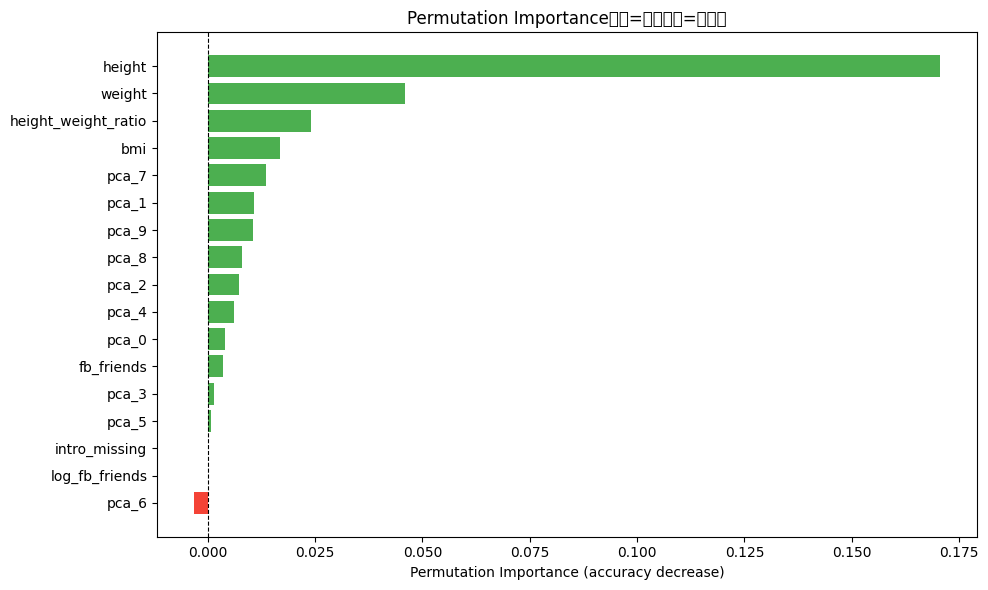

特徵 Permutation Importance 排名：
  height                    : +0.1706  [保留]
  weight                    : +0.0459  [保留]
  height_weight_ratio       : +0.0241  [保留]
  bmi                       : +0.0168  [保留]
  pca_7                     : +0.0135  [保留]
  pca_1                     : +0.0109  [保留]
  pca_9                     : +0.0107  [保留]
  pca_8                     : +0.0080  [保留]
  pca_2                     : +0.0074  [保留]
  pca_4                     : +0.0062  [保留]
  pca_0                     : +0.0040  [保留]
  fb_friends                : +0.0036  [保留]
  pca_3                     : +0.0014  [保留]
  pca_5                     : +0.0007  [保留]
  intro_missing             : +0.0000  [移除]
  log_fb_friends            : +0.0000  [移除]
  pca_6                     : -0.0031  [移除]


In [12]:
# 先用全部特徵訓練，計算 Permutation Importance
imputer_temp = SimpleImputer(strategy='median')
X_train_imputed = imputer_temp.fit_transform(X_train_full)

model_temp = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    min_child_samples=10, class_weight=class_weight_dict,
    random_state=42, verbose=-1
)

# 用 CV 的方式計算 permutation importance（更穩定）
cv_pi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
perm_scores = []
for tr_idx, val_idx in cv_pi.split(X_train_imputed, y_encoded):
    model_temp.fit(X_train_imputed[tr_idx], y_encoded[tr_idx])
    result = permutation_importance(
        model_temp, X_train_imputed[val_idx], y_encoded[val_idx],
        n_repeats=10, random_state=42, scoring='accuracy'
    )
    perm_scores.append(result.importances_mean)

perm_importance_mean = np.mean(perm_scores, axis=0)

# 視覺化
sorted_idx = np.argsort(perm_importance_mean)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4CAF50' if perm_importance_mean[i] > 0 else '#F44336' for i in sorted_idx]
ax.barh([feature_names[i] for i in sorted_idx], perm_importance_mean[sorted_idx], color=colors)
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Permutation Importance (accuracy decrease)')
ax.set_title('Permutation Importance（綠=有用，紅=噪聲）')
plt.tight_layout()
plt.show()

print("特徵 Permutation Importance 排名：")
for i in np.argsort(perm_importance_mean)[::-1]:
    status = "保留" if perm_importance_mean[i] > 0 else "移除"
    print(f"  {feature_names[i]:25s} : {perm_importance_mean[i]:+.4f}  [{status}]")

In [13]:
# 移除 importance <= 0 的噪聲特徵
keep_mask = perm_importance_mean > 0
removed_features = [feature_names[i] for i in range(len(feature_names)) if not keep_mask[i]]
kept_features = [feature_names[i] for i in range(len(feature_names)) if keep_mask[i]]

if removed_features:
    print(f"移除噪聲特徵（importance <= 0）：{removed_features}")
else:
    print("沒有需要移除的噪聲特徵")

print(f"保留特徵（{len(kept_features)}）：{kept_features}")

X_train = X_train_full[:, keep_mask]
X_test  = X_test_full[:, keep_mask]
print(f"\n篩選後特徵維度：{X_train.shape[1]}")

移除噪聲特徵（importance <= 0）：['log_fb_friends', 'pca_6', 'intro_missing']
保留特徵（14）：['height', 'weight', 'fb_friends', 'bmi', 'height_weight_ratio', 'pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_7', 'pca_8', 'pca_9']

篩選後特徵維度：14


## Step 10: Cross-Validation 評估

In [14]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# OOF predictions
oof_preds = cross_val_predict(pipe, X_train, y_encoded, cv=cv, method='predict')
oof_labels = [inv_label_map[p] for p in oof_preds]

print(f"=== {N_FOLDS}-Fold Stratified CV ===")
print(classification_report(y_train, oof_labels))

# 各 Fold accuracy
fold_accs = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train, y_encoded)):
    pipe.fit(X_train[tr_idx], y_encoded[tr_idx])
    preds = pipe.predict(X_train[val_idx])
    acc = accuracy_score(y_encoded[val_idx], preds)
    fold_accs.append(acc)
    print(f"  Fold {fold+1}: accuracy = {acc:.4f}")

print(f"\n  CV Mean accuracy : {np.mean(fold_accs):.4f}")
print(f"  CV Std  accuracy : {np.std(fold_accs):.4f}")

=== 5-Fold Stratified CV ===
              precision    recall  f1-score   support

           1       0.91      0.92      0.92       316
           2       0.75      0.75      0.75       107

    accuracy                           0.87       423
   macro avg       0.83      0.83      0.83       423
weighted avg       0.87      0.87      0.87       423

  Fold 1: accuracy = 0.8941
  Fold 2: accuracy = 0.9059
  Fold 3: accuracy = 0.7882
  Fold 4: accuracy = 0.9048
  Fold 5: accuracy = 0.8810

  CV Mean accuracy : 0.8748
  CV Std  accuracy : 0.0442


## Step 11: 預測 + 輸出 Submission

In [15]:
# 完整訓練 + 預測
pipe.fit(X_train, y_encoded)
test_preds_encoded = pipe.predict(X_test)
test_preds = [inv_label_map[p] for p in test_preds_encoded]

# 輸出 submission
submission = pd.DataFrame({
    'id':     test['id'],
    'gender': test_preds
})
submission.to_csv('../submission/submission_PI_bge.csv', index=False)

print(f"submission_PI_bge.csv 已輸出（{len(submission)} 筆）")
print(f"\n預測分布：")
print(submission['gender'].value_counts().sort_index())
print(f"\n預測比例：")
print(submission['gender'].value_counts(normalize=True).sort_index().round(3))

submission_PI_bge.csv 已輸出（426 筆）

預測分布：
gender
1    298
2    128
Name: count, dtype: int64

預測比例：
gender
1    0.7
2    0.3
Name: proportion, dtype: float64


## 附錄

### 重現步驟

```bash
# 1. 環境
conda activate myenv
pip install sentence-transformers lightgbm scikit-learn pandas numpy matplotlib seaborn

# 2. 若需重新生成 embedding（刪掉快取後會自動重跑）
rm train_intro_emb.npy test_intro_emb.npy

# 3. 執行本 notebook 的所有 cell
```

### 檔案說明
| 檔案 | 用途 |
|------|------|
| `Boy_or_Girl_PI_bge.ipynb` | 本 notebook，完整流程 |
| `PI_bge.py` | 同等邏輯的 .py 版本 |
| `train_intro_emb.npy` / `test_intro_emb.npy` | bge-large-en-v1.5 的 1024d embedding 快取 |
| `submission_PI_bge.csv` | 最終提交檔（acc=0.8638） |

### 相較於前一版（SI_bge, acc=0.8497）的改進總結

| 改動 | 說明 | 效果 |
|------|------|------|
| 加入衍生特徵 | BMI、身高體重比、log_fb_friends | 提供體型交互資訊，提升模型區分力 |
| Permutation Importance 篩選 | 取代 Split Importance，移除噪聲特徵 | 減少過擬合，提升泛化能力 |

### 嘗試過但未改善的方向

| 嘗試 | 結果 | 結論 |
|------|------|------|
| 換用 MiniLM (384d) embedding | Kaggle 分數未提升 | bge (1024d) 語意資訊更豐富 |
| 移除 height_weight_ratio | CV acc 提升但 Kaggle 降至 0.8591 | CV 與 Kaggle 不完全一致，三個衍生特徵缺一不可 |
| Ensemble 方法 | 0.8403 / 0.8215 | 反而比單一模型差 |

### 關鍵決策紀錄
| 決策 | 原因 |
|------|------|
| 選用 height, weight, fb_friends 作為 base 特徵 | EDA 中 gender 分組統計差異最大的三個數值欄位 |
| 不使用 star_sign, phone_os | EDA 顯示星座對性別區分度弱；phone_os 缺失率高且有異常類別 |
| 使用 bge-large-en-v1.5 | 1024d 比 MiniLM（384d）保留更多語意資訊，實測分數更高 |
| PCA 降至 10 維 | 平衡資訊保留（~47% 變異量）與小樣本過擬合風險 |
| 加入 BMI / height_weight_ratio / log_fb_friends | 體型交互資訊對性別分類有幫助，三者缺一不可（實驗驗證） |
| Permutation Importance 篩選 | 比 Split Importance 更準確評估特徵貢獻，有效移除噪聲特徵 |
| class_weight 平衡 | gender=1 佔 ~75%，不平衡處理避免模型偏向多數類 |
| max_depth=4, min_child_samples=10 | 僅 ~400 筆訓練資料，控制模型複雜度防止過擬合 |

yt,fb範圍
Missforest填補
清洗過後採樣